# Etapa 1 — Análise Exploratória dos Dados (EDA)

**Objetivo:** Entender o 3W Dataset antes de qualquer processamento ou modelagem.

O 3W Dataset contém séries temporais de sensores de pressão e temperatura registradas em **2.228 poços de petróleo offshore**, cobrindo 10 tipos de eventos (operação normal + 9 tipos de falha). Antes de treinar qualquer modelo, precisamos responder perguntas básicas sobre os dados:

| Pergunta | Seção |
|----------|-------|
| Quantas instâncias existem por tipo de falha? | 1.1 |
| Qual é o formato do dataset? | 1.2 |
| Como são as séries temporais de cada falha? | 1.3 |
| O que são os três estados operacionais (normal, transiente, ativo)? | 1.4 |
| Quais sensores têm mais dados faltantes? | 1.5 |
| Quanto tempo dura cada instância? | 1.6 |

**Estrutura do notebook:**
- Seções 1.1–1.2: inspeção inicial — contagem de instâncias e estrutura do dataset
- Seções 1.3–1.4: visualização das séries temporais e entendimento dos rótulos
- Seções 1.5–1.6: análise completa sobre todas as 2.228 instâncias (dados brutos)
- Seção 1.7: síntese das conclusões para orientar as etapas seguintes

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from config import FAULT_CLASSES, KEY_SENSORS
from src.data_loader import count_instances, load_sample
from src.visualization import (
    plot_class_distribution,
    plot_correlation_heatmap,
    plot_missing_data,
    plot_time_series,
)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1.1 Contagem de instâncias por classe

Cada **instância** é um arquivo Parquet com a série temporal completa de um evento em um poço. Contamos as instâncias por classe e por tipo de fonte sem carregar nenhum dado na memória — basta listar os arquivos no disco.

**Tipos de fonte no 3W Dataset:**
- `WELL`: dados reais coletados de poços instrumentados em campo
- `SIMULATED`: gerados por simulador numérico (OLGA) da Petrobras
- `DRAWN`: criados manualmente por especialistas para cobrir cenários raros

O desbalanceamento entre classes é esperado e impacta a escolha de métricas (`F1-macro`) e estratégias de treino (`class_weight='balanced'`).

In [2]:
counts = count_instances()
print('\nInstâncias por classe e tipo de fonte:')
print(counts.to_string())


Instâncias por classe e tipo de fonte:
                               fault_label  total  WELL  SIMULATED  DRAWN
fault_class                                                              
0                                   Normal    594   594          0      0
1                   Aumento Abrupto de BSW    128     4        114     10
2               Fechamento Espúrio da DHSV     38    22         16      0
3                         Golfadas Severas    106    32         74      0
4                   Instabilidade de Fluxo    343   343          0      0
5            Perda Rápida de Produtividade    450    11        439      0
6                  Restrição Rápida no PCK    221     6        215      0
7                       Incrustação no PCK     46    36          0     10
8             Hidrato na Linha de Produção     95    14         81      0
9              Hidrato na Linha de Serviço    207    57        150      0


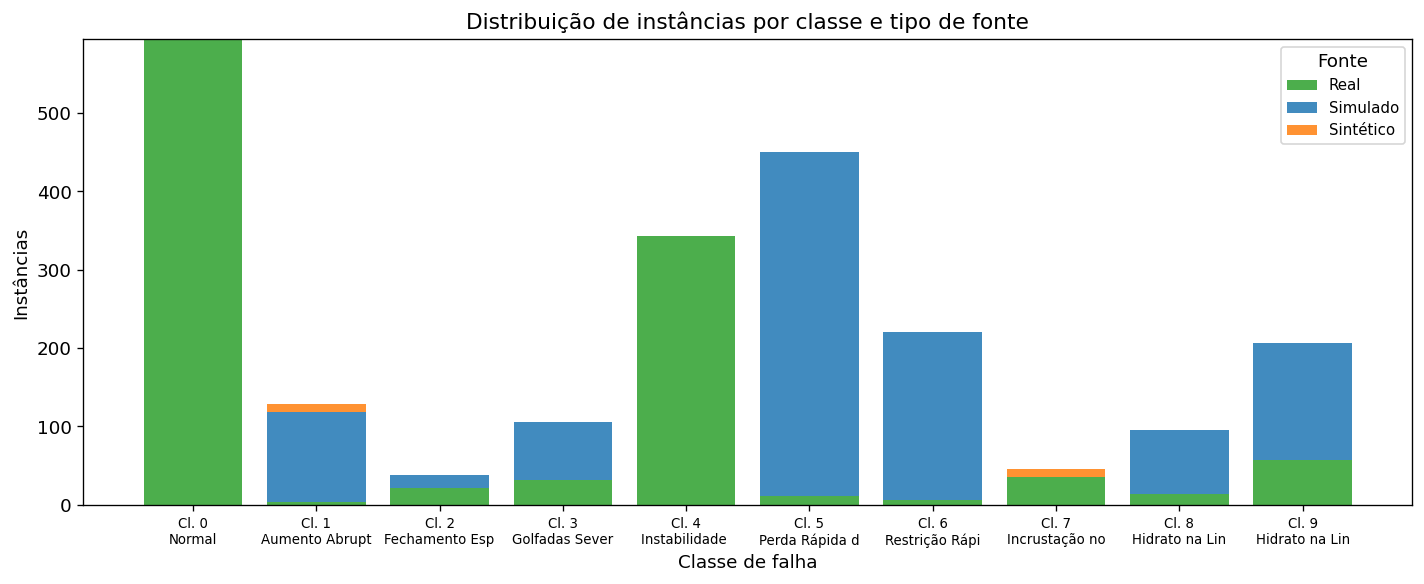

In [3]:
from pathlib import Path

LATEX_FIGS = Path('../docs/latex/unbtex-example/figuras')

source_configs = [('WELL', 'Real', '#2ca02c'), ('SIMULATED', 'Simulado', '#1f77b4'), ('DRAWN', 'Sintético', '#ff7f0e')]
classes_sorted = sorted(FAULT_CLASSES.keys())
labels = [f"Cl. {c}\n{FAULT_CLASSES[c][:14]}" for c in classes_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = [0] * len(classes_sorted)
for source, label, color in source_configs:
    values = [int(counts.loc[c, source]) if source in counts.columns else 0 for c in classes_sorted]
    ax.bar(labels, values, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_ylabel('Instâncias')
ax.set_xlabel('Classe de falha')
ax.set_title('Distribuição de instâncias por classe e tipo de fonte')
ax.legend(title='Fonte')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.savefig('../results/figures/eda/distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.savefig(LATEX_FIGS / 'distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 Estrutura do dataset

Cada arquivo Parquet do 3W representa uma instância — a série temporal completa de um evento em um poço. Ao carregar qualquer instância, o DataFrame resultante tem sempre o mesmo formato:

| Grupo | Colunas | Descrição |
|-------|---------|-----------|
| **Sensores** | `P-PDG`, `T-PDG`, `P-TPT`, `T-TPT`, `P-MON-CKP`, `T-JUS-CKP`, `P-JUS-CKGL`, `QGL` + outros | Medições brutas em 1 Hz; podem conter `NaN` |
| **Rótulos** | `class`, `state` | Estado operacional em cada segundo (`NaN`=normal, `1–9`=ativo, `101–109`=transiente) |
| **Metadados** | `instance_id`, `fault_class`, `fault_label`, `source_type` | Identificação e origem da instância |

Cada linha corresponde a **1 segundo** de operação. A coluna `class` é o rótulo central do TCC: é ela que os modelos precisam prever.

> A célula abaixo carrega uma amostra de 3 instâncias por classe para uso nas seções 1.3 e 1.4. As seções 1.5 e 1.6 usam todos os dados brutos via `iter_classes()`.

In [4]:
df_sample = load_sample(n_instances_per_class=3)

print(f'Dimensões: {df_sample.shape[0]:,} linhas × {df_sample.shape[1]} colunas')
print(f'Instâncias carregadas: {df_sample["instance_id"].nunique()}  '
      f'({df_sample["fault_class"].nunique()} classes × 3 instâncias)\n')
print('Tipos de dados por coluna:')
print(df_sample.dtypes.to_string())

Dimensões: 2,015,200 linhas × 33 colunas
Instâncias carregadas: 12  (10 classes × 3 instâncias)

Tipos de dados por coluna:
ABER-CKGL        float64
ABER-CKP         float64
ESTADO-DHSV      float64
ESTADO-M1        float64
ESTADO-M2        float64
ESTADO-PXO       float64
ESTADO-SDV-GL    float64
ESTADO-SDV-P     float64
ESTADO-W1        float64
ESTADO-W2        float64
ESTADO-XO        float64
P-ANULAR         float64
P-JUS-BS         float64
P-JUS-CKGL       float64
P-JUS-CKP        float64
P-MON-CKGL       float64
P-MON-CKP        float64
P-MON-SDV-P      float64
P-PDG            float64
PT-P             float64
P-TPT            float64
QBS              float64
QGL              float64
T-JUS-CKP        float64
T-MON-CKP        float64
T-PDG            float64
T-TPT            float64
class              Int16
state              Int16
instance_id       object
fault_class        int64
fault_label       object
source_type       object


In [5]:
df_sample.head()

,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,instance_id,fault_class,fault_label,source_type
0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.64463,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
1,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63828,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
2,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63194,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
3,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.62558,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
4,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.61923,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL


## 1.3 Visualização das séries temporais por classe

Plotamos uma instância representativa de cada tipo de falha para entender como os sensores se comportam ao longo do tempo. A análise visual é essencial para:

- Confirmar que os padrões de sensor fazem sentido físico (ex.: queda de pressão em hidratos)
- Identificar quais sensores são mais informativos para cada classe
- Ver a progressão temporal **Normal → Transiente → Ativo**

**Código de cores do fundo:**
- **Verde** — operação normal
- **Amarelo** — período transiente (falha se desenvolvendo)
- **Vermelho** — falha ativa

Os 4 sensores exibidos são os de maior cobertura no dataset: `P-TPT`, `T-TPT`, `P-MON-CKP` e `T-JUS-CKP`.

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_0.png


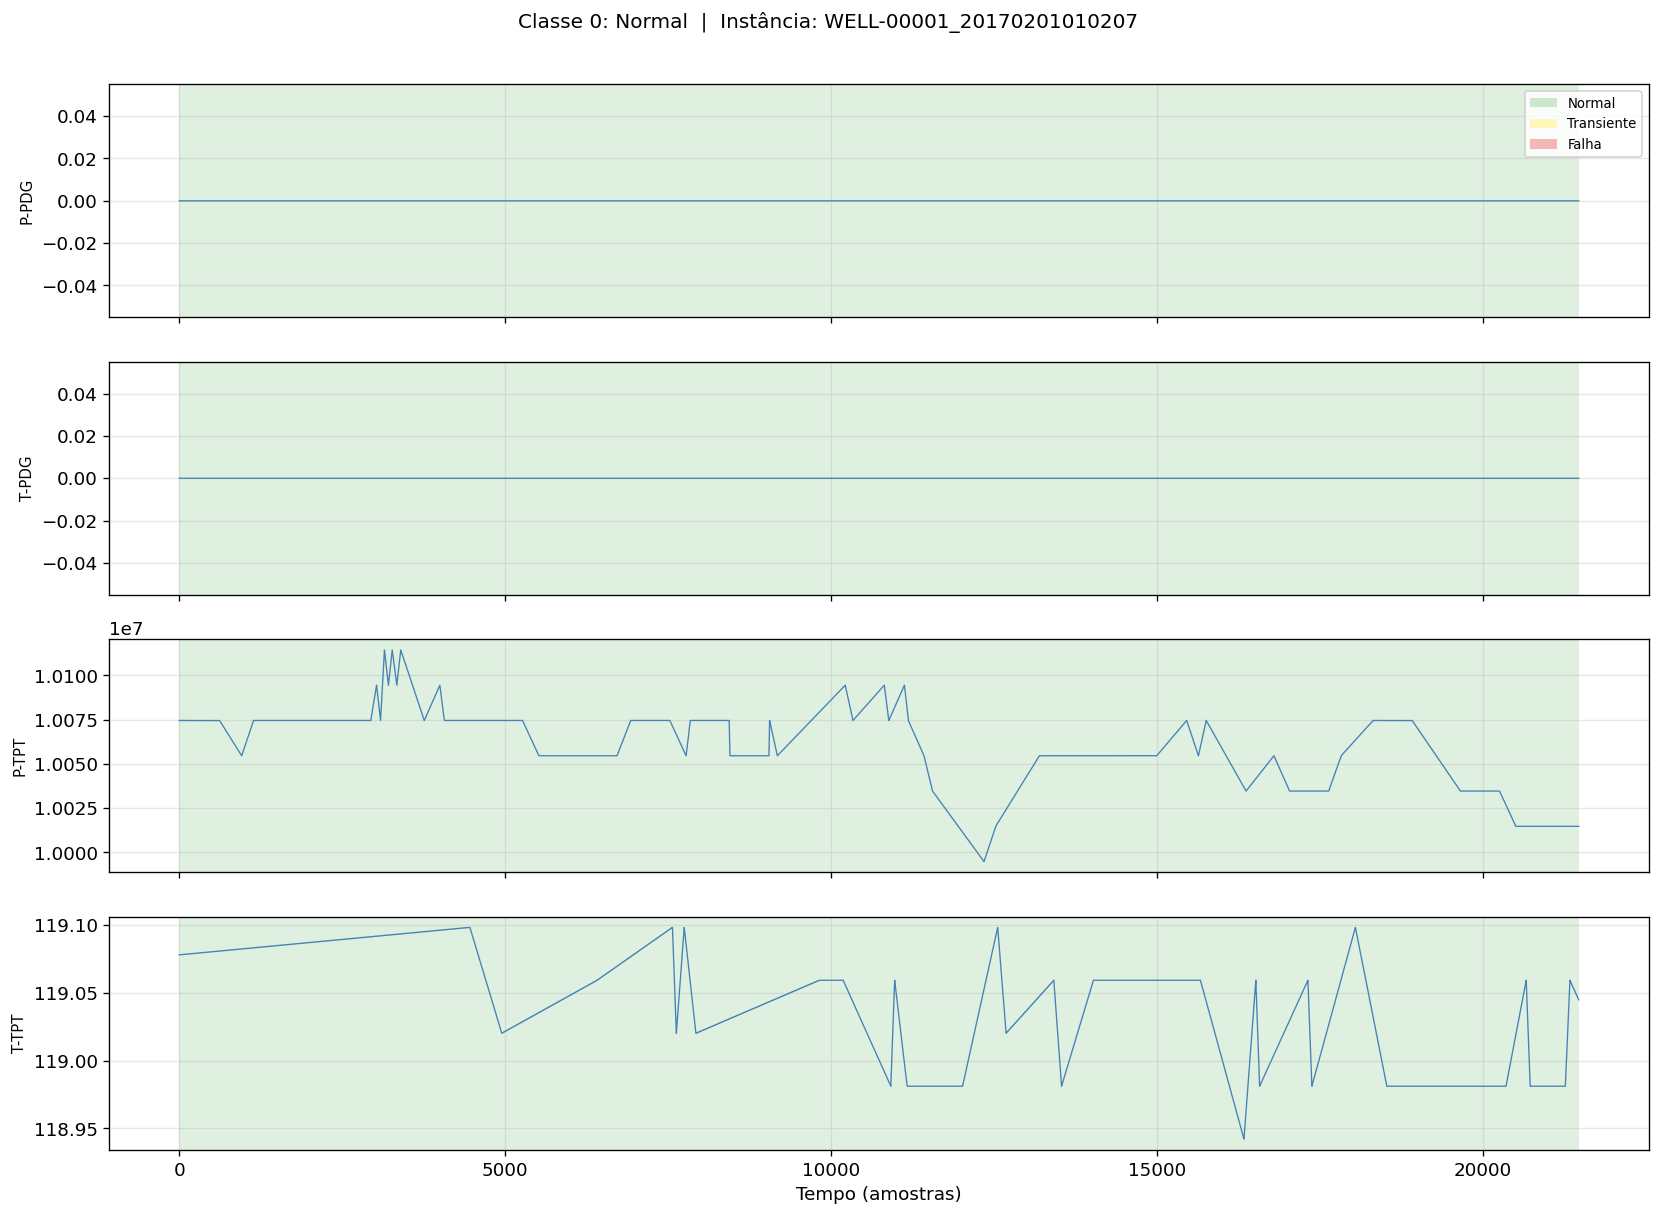

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_1.png


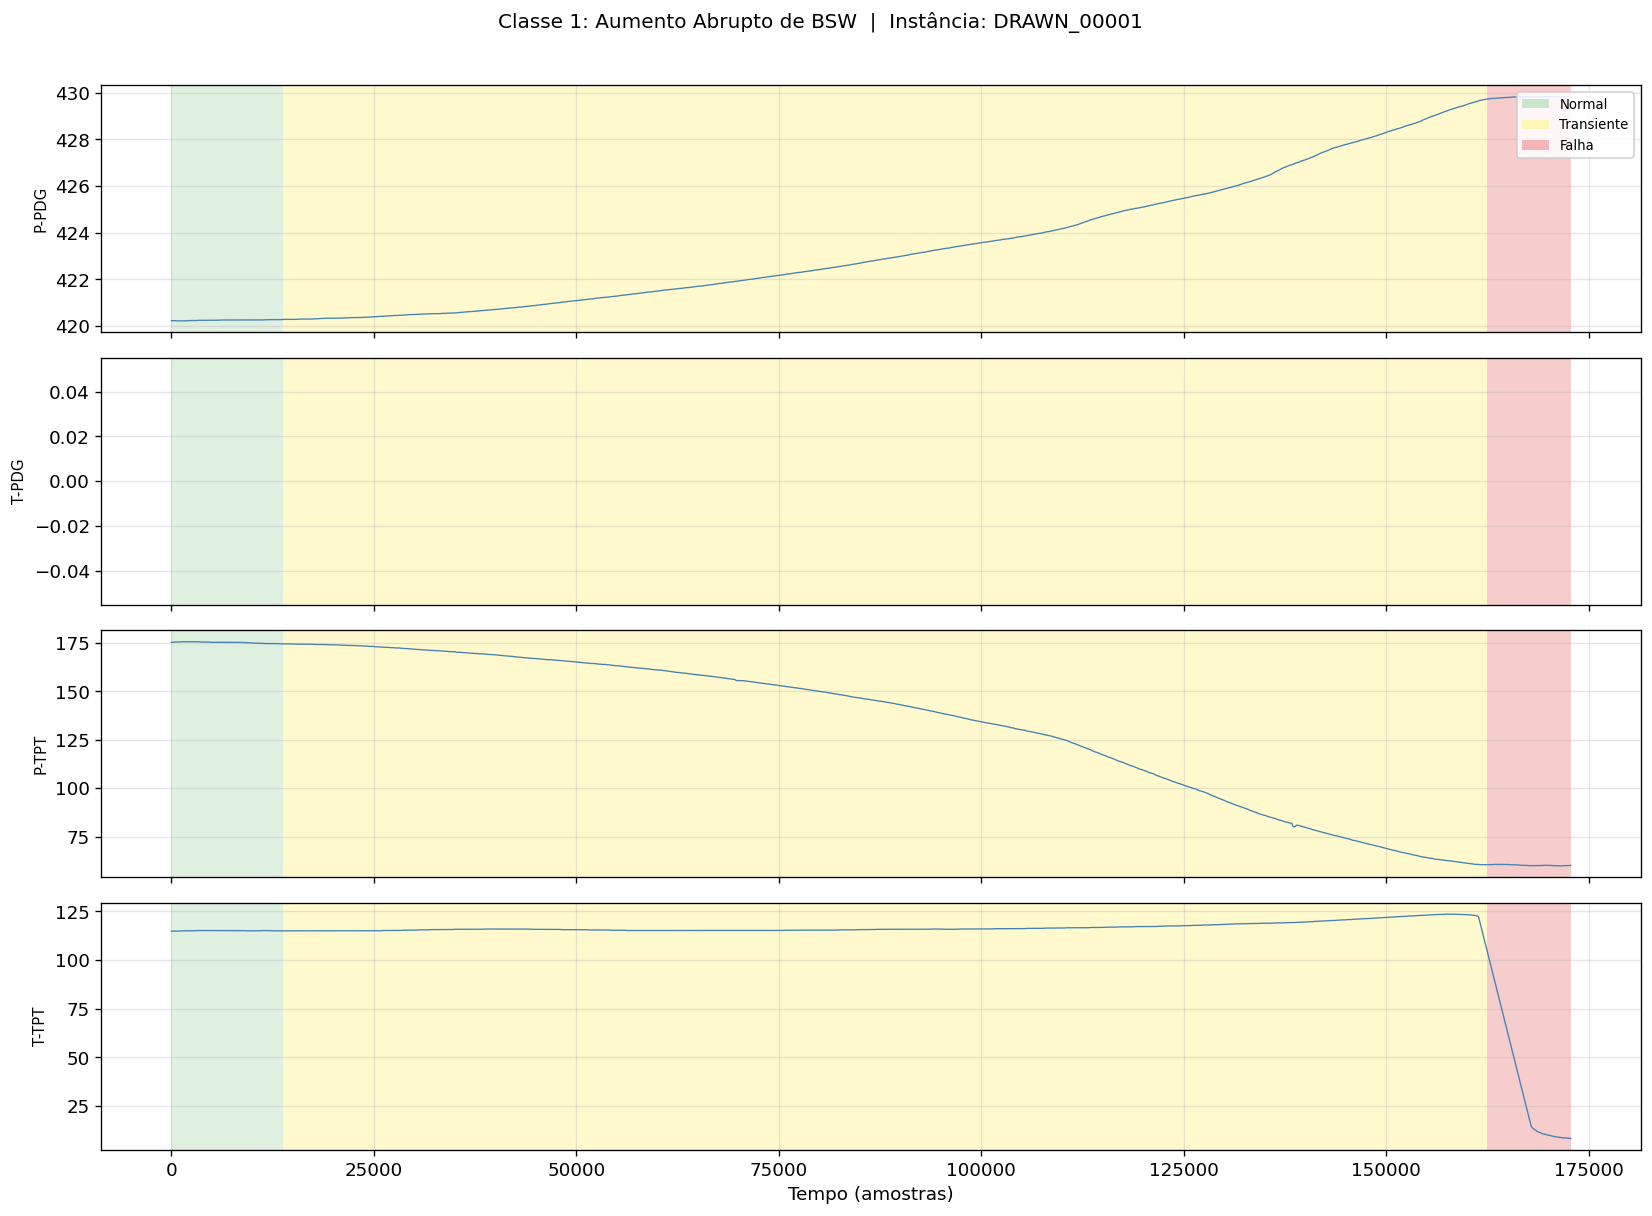

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_2.png


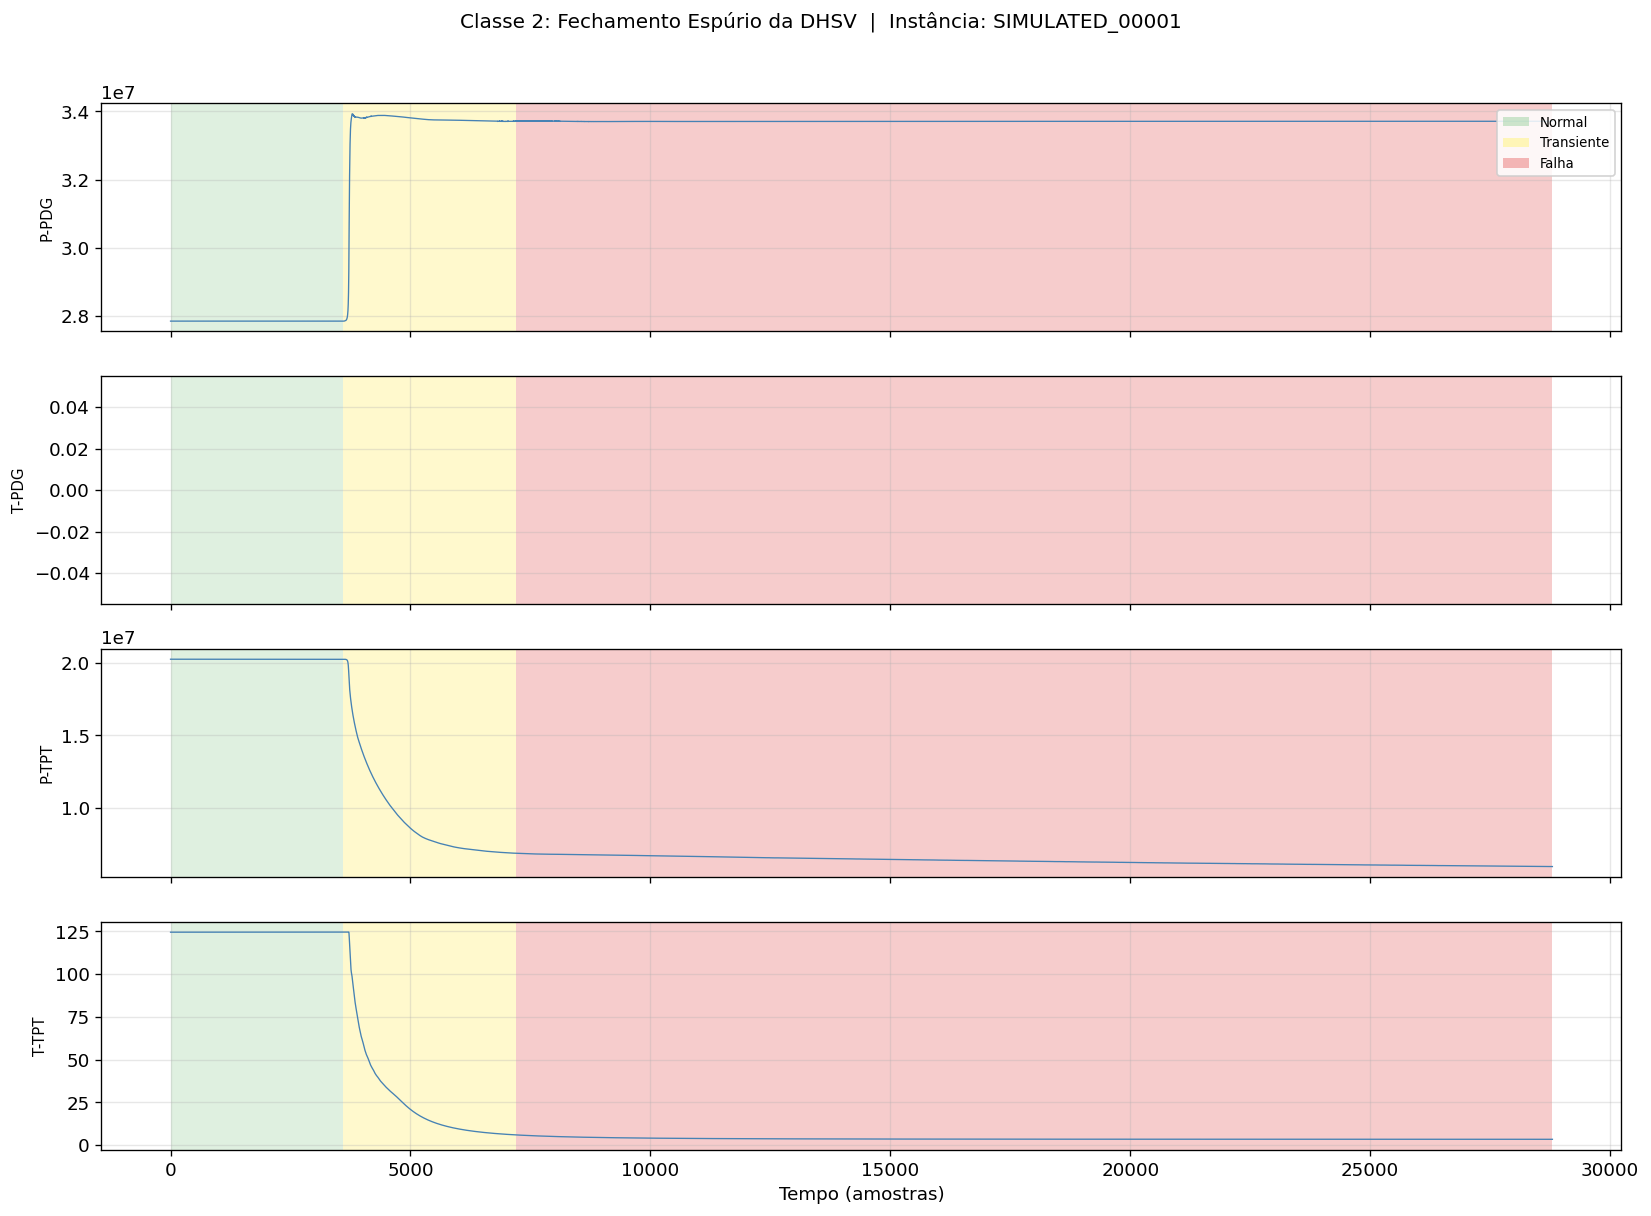

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_3.png


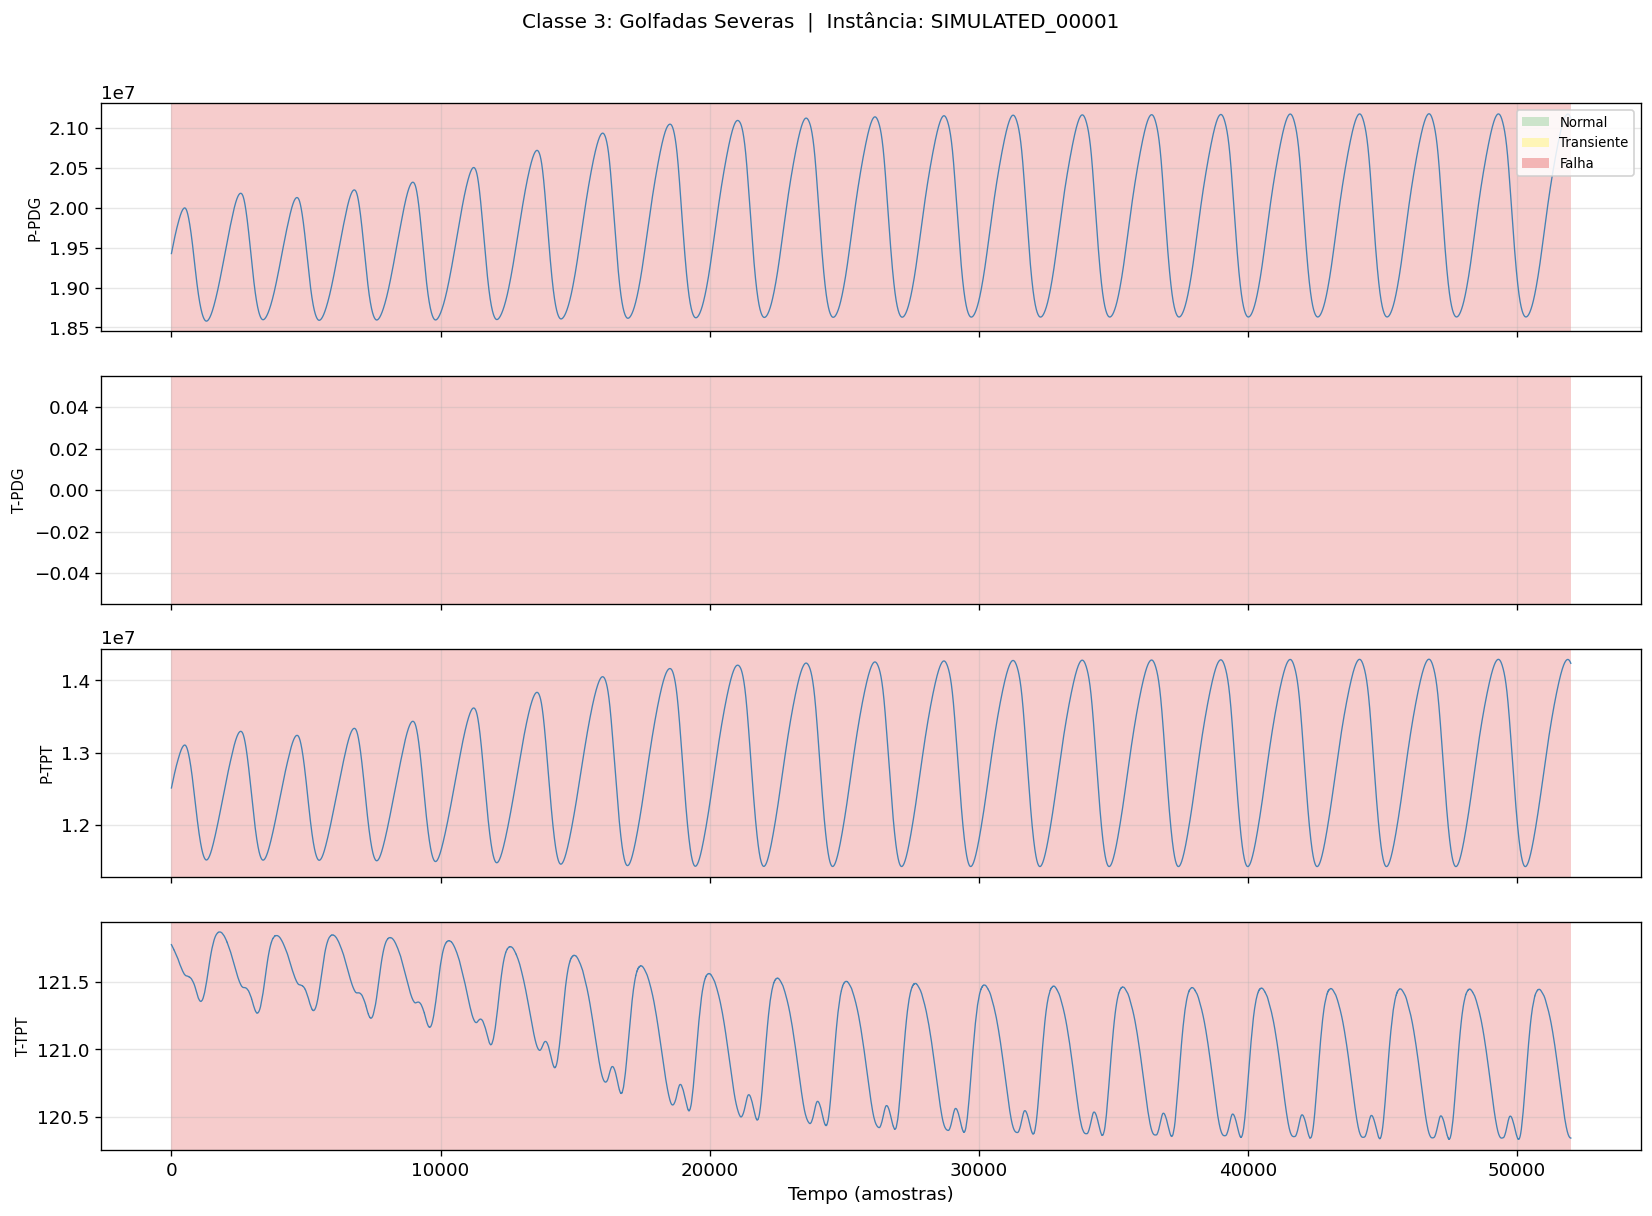

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_4.png


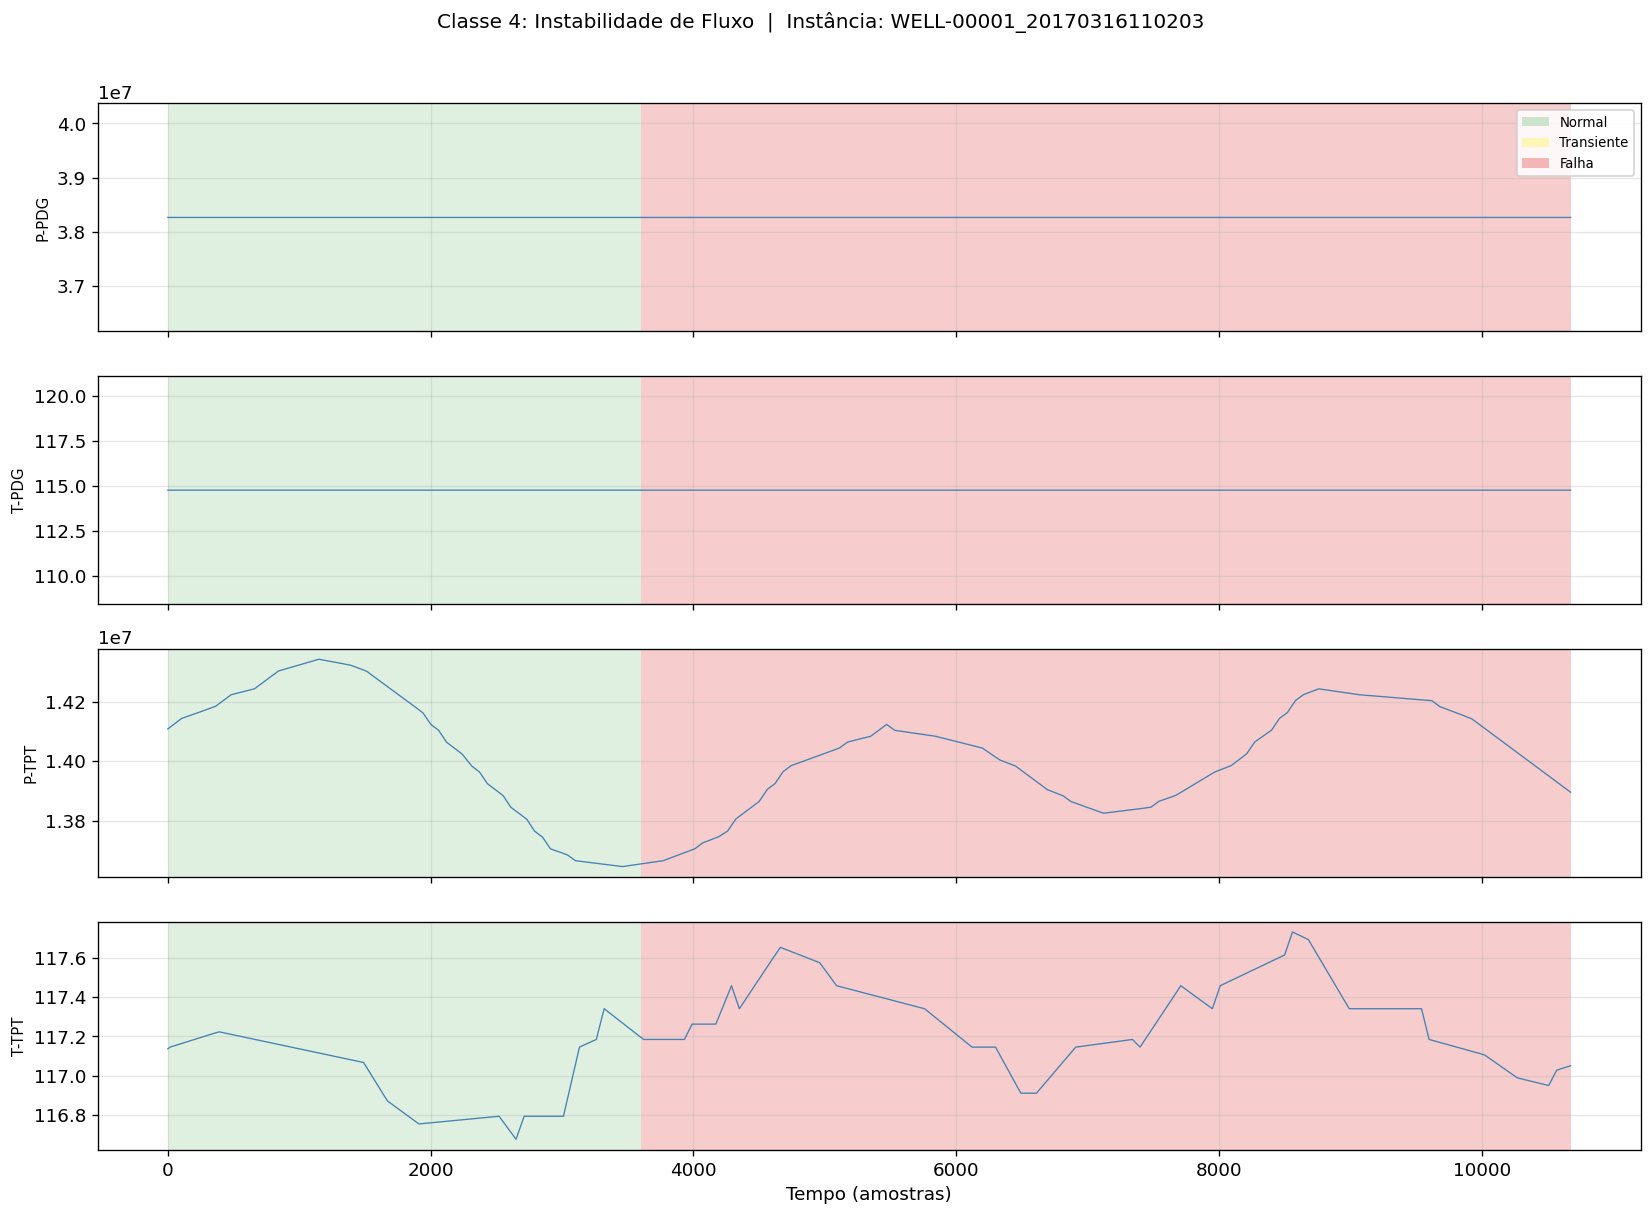

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_5.png


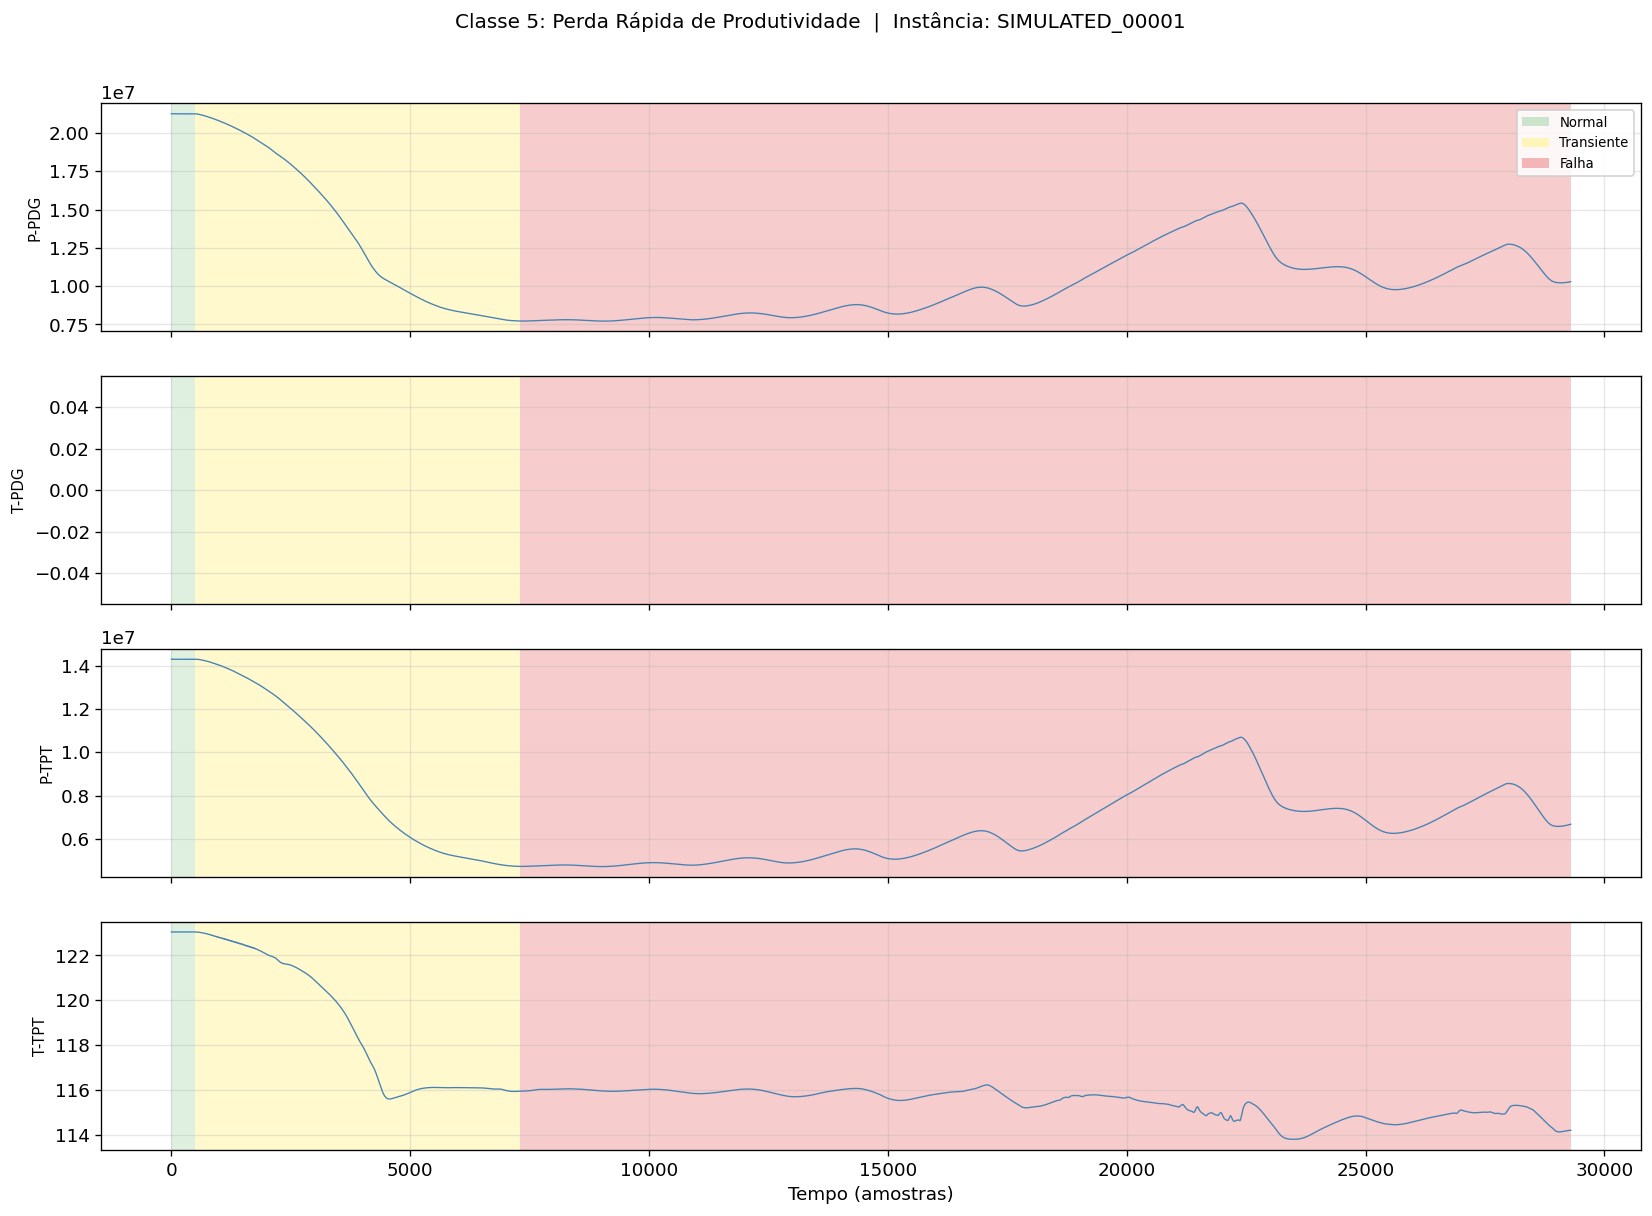

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_6.png


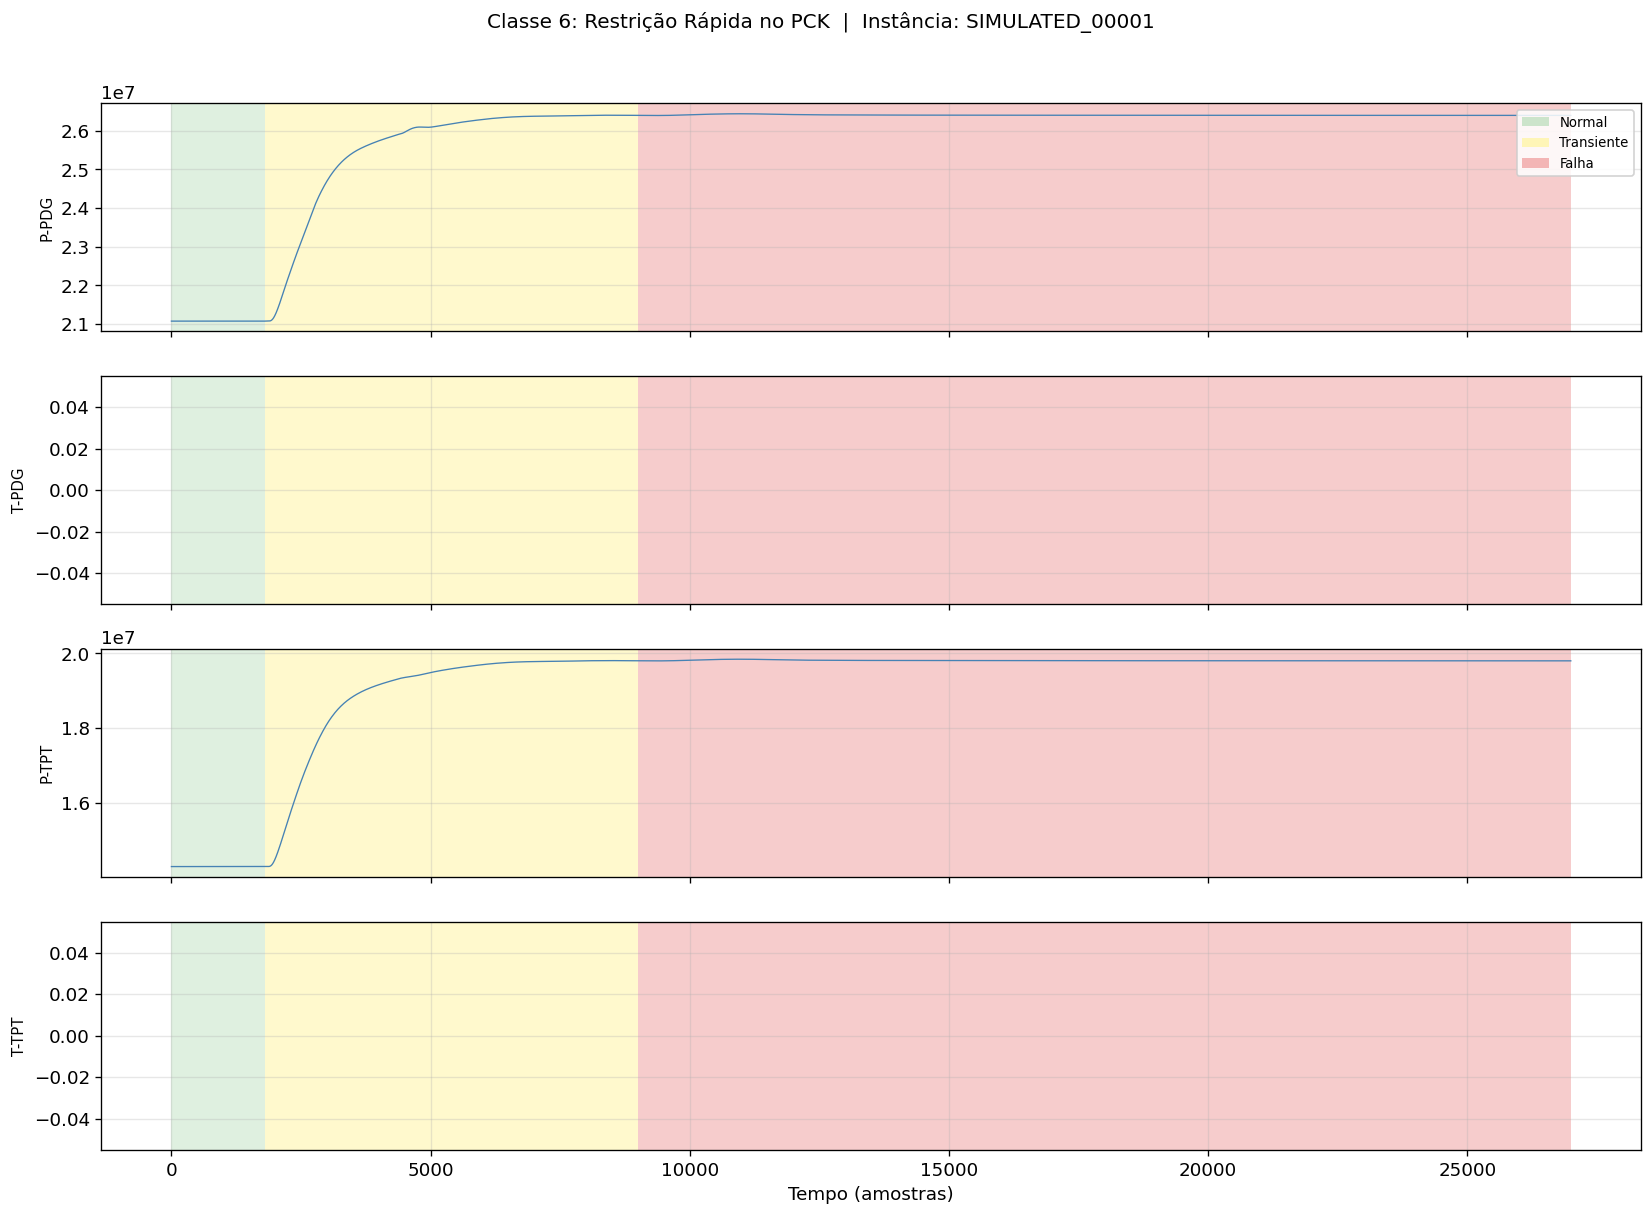

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_7.png


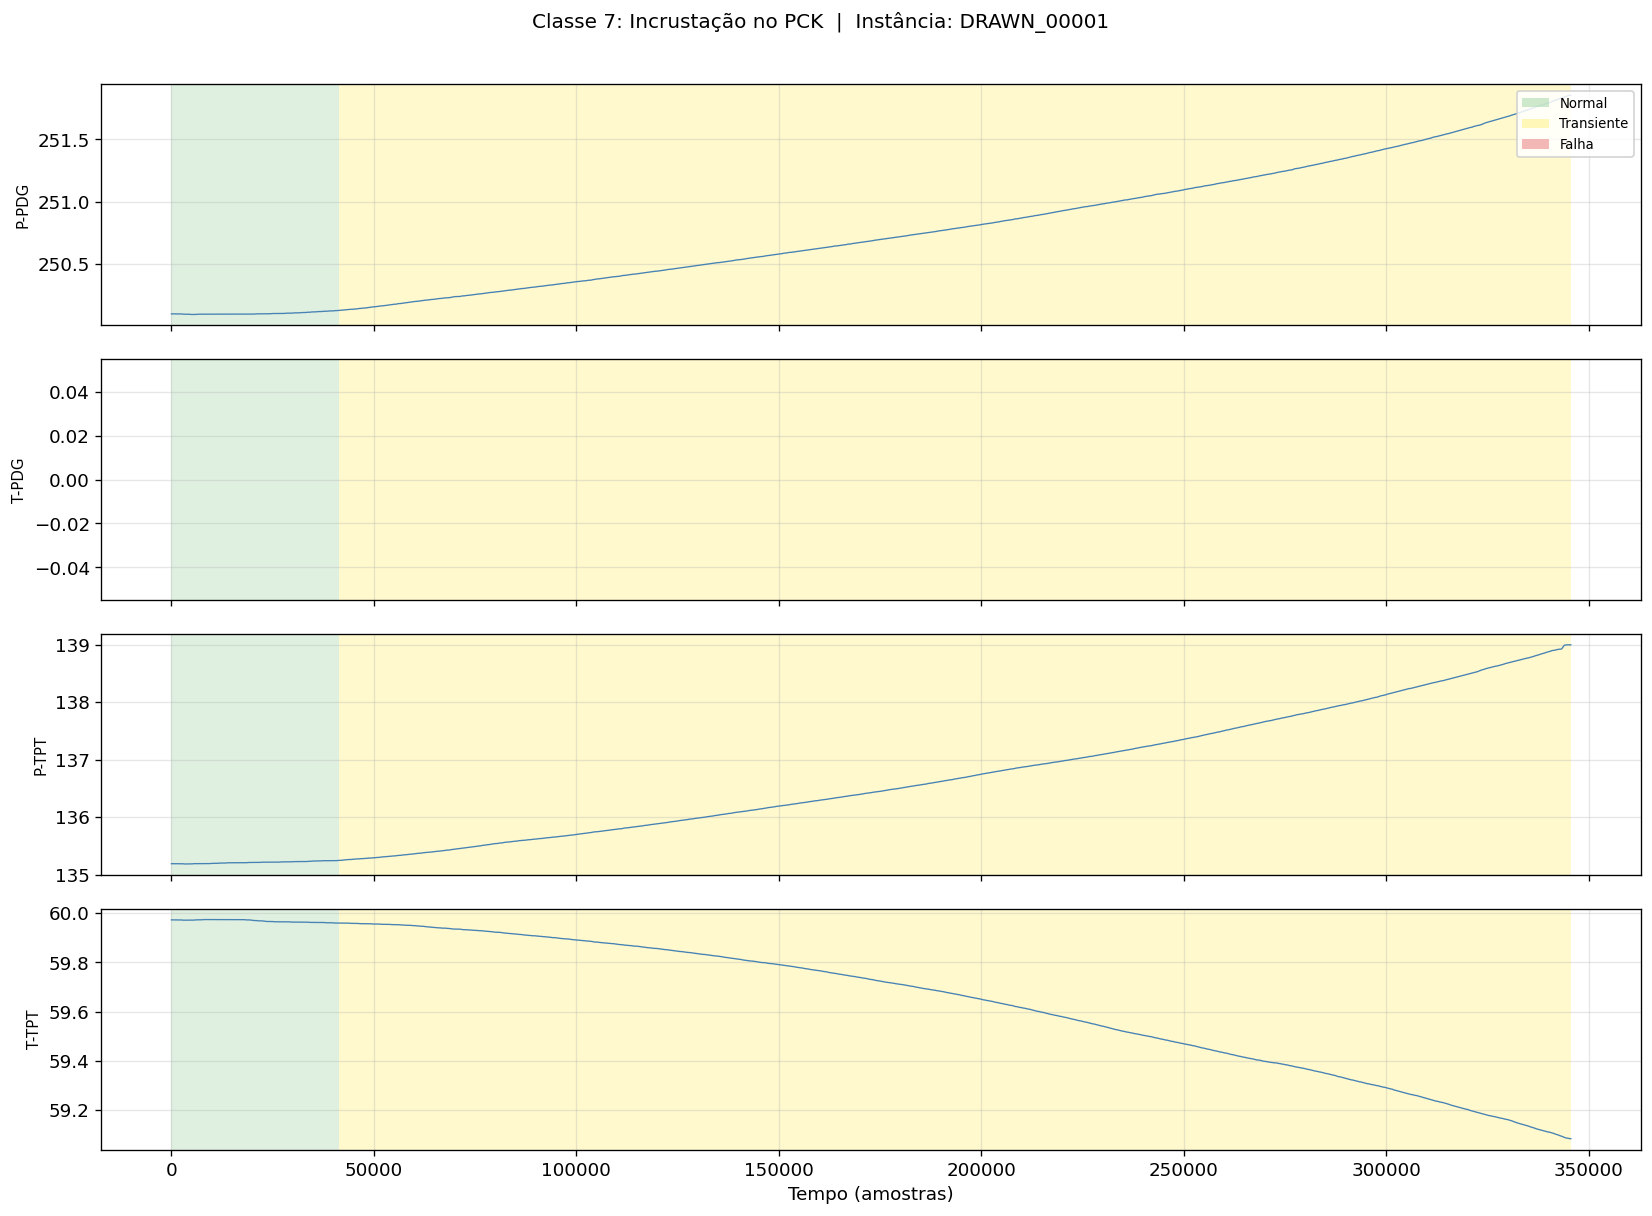

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_8.png


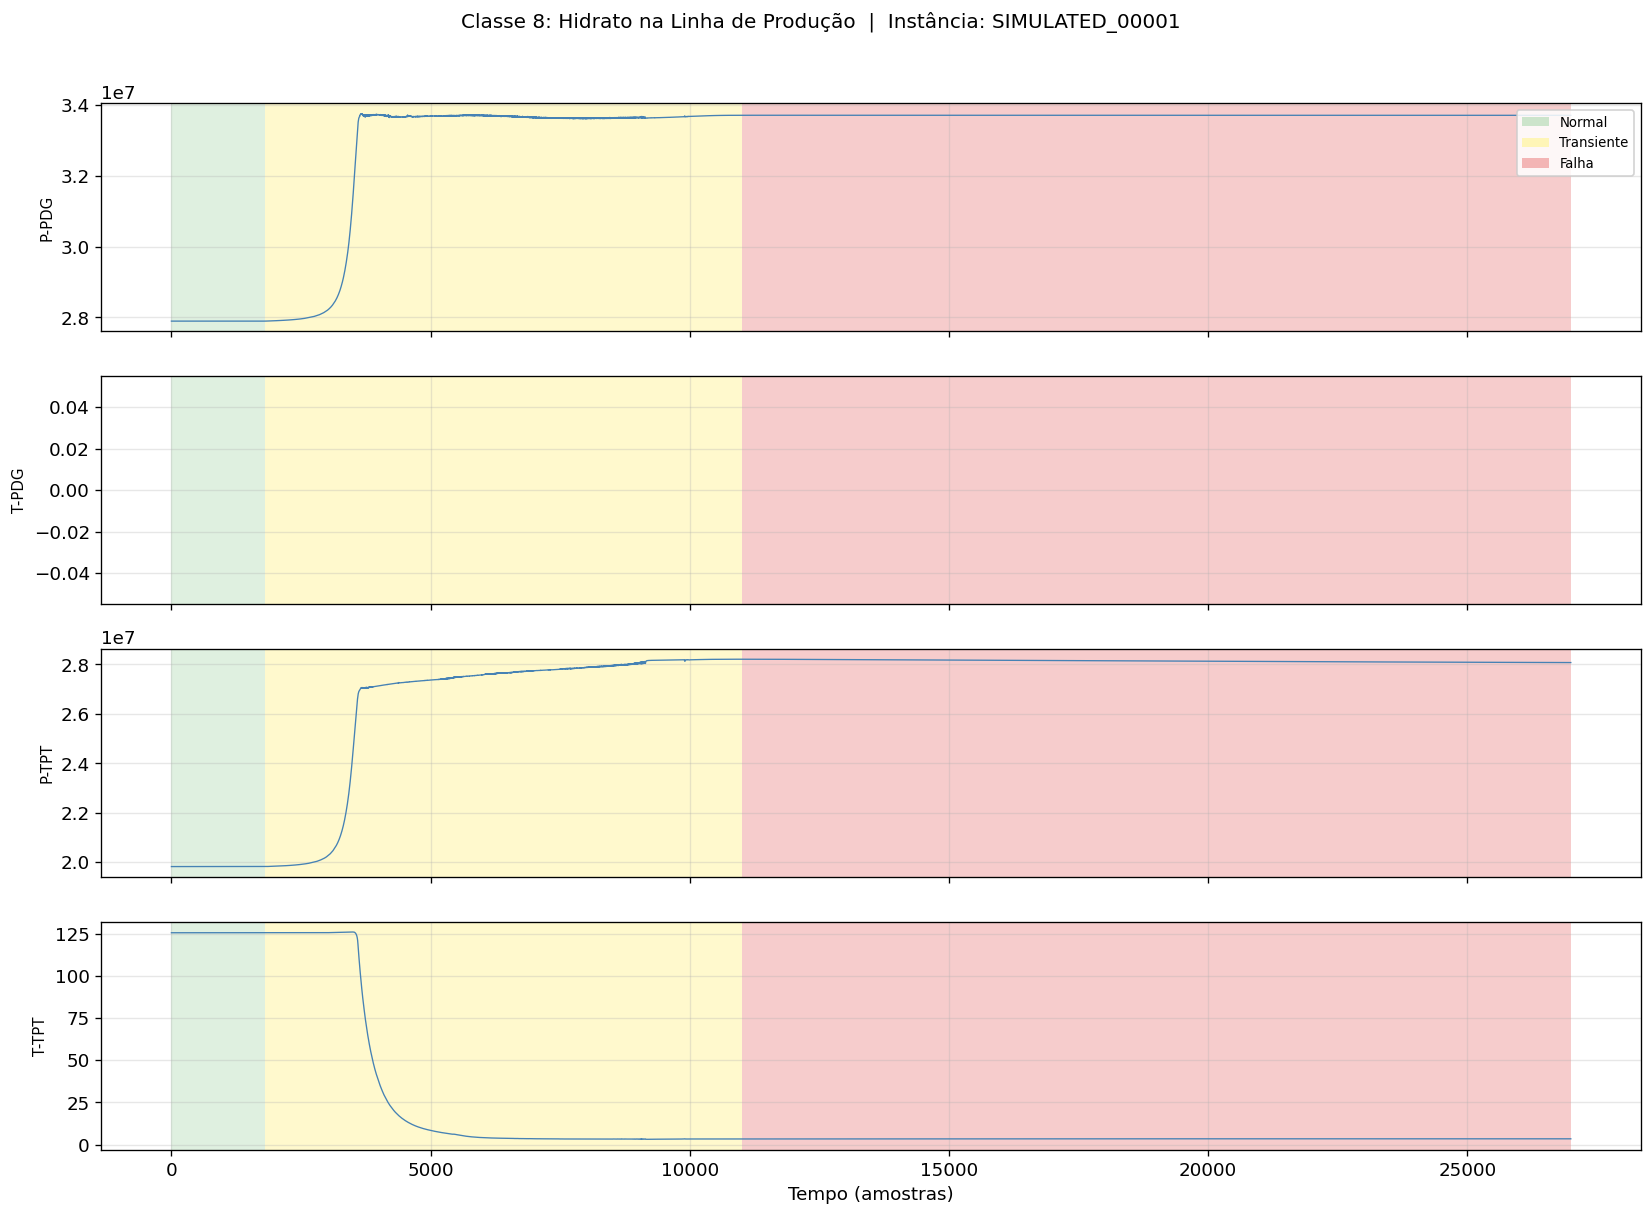

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_9.png


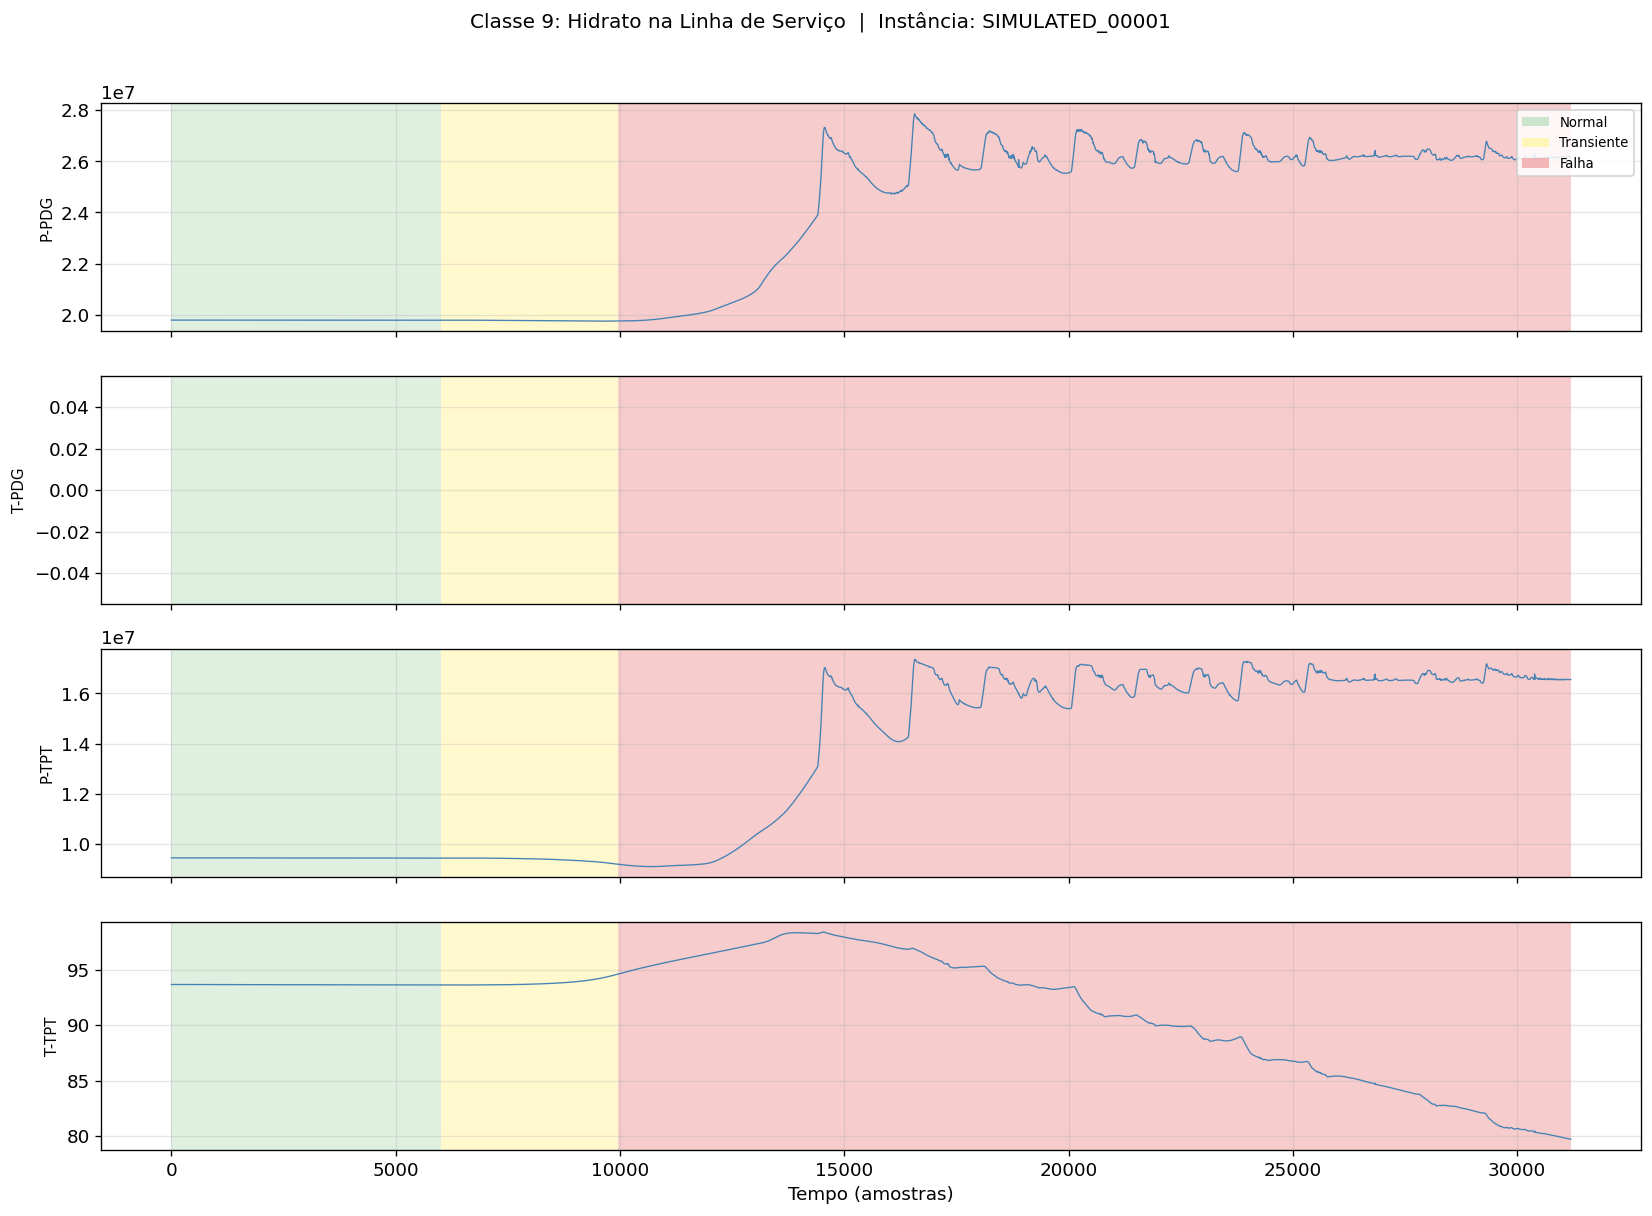

In [6]:
for fault_class, label in FAULT_CLASSES.items():
    df_class = df_sample[df_sample['fault_class'] == fault_class]
    if df_class.empty:
        continue
    first_instance = df_class['instance_id'].iloc[0]
    df_inst = df_class[df_class['instance_id'] == first_instance]
    sensors_available = [s for s in KEY_SENSORS if s in df_inst.columns]
    fig = plot_time_series(
        df_inst,
        sensors=sensors_available[:4],
        save_name=f'serie_temporal_classe_{fault_class}'
    )
    plt.show()

## 1.4 Os Três Estados Operacionais

O 3W Dataset rotula **cada segundo** de cada instância com um estado operacional. Esses rótulos são a base da tarefa de **detecção de estado operacional** — o objetivo principal do TCC.

| Código | Estado | Descrição |
|--------|--------|-----------|
| `NaN` / `0` | **Normal** | Poço operando sem anomalias |
| `101`–`109` | **Transiente** | Falha em desenvolvimento — janela de detecção precoce |
| `1`–`9` | **Ativo** | Falha instalada — evento confirmado |

O número do estado ativo corresponde ao tipo de falha (ex.: `2` = DHSV ativa, `102` = DHSV em transição). As classes `103` e `104` (transientes de Golfadas e Instabilidade) não existem no dataset público.

**Por que isso importa para o modelo?**
A modelagem classifica **janelas de 300 s** em um desses 17 estados. Detectar o estado transiente com antecedência é o objetivo mais valioso operacionalmente: ainda há tempo para intervenção antes de a falha se instalar completamente.

O exemplo abaixo mostra a progressão de uma instância DHSV real:

In [7]:
# Mostrar como uma instância evolui entre estados: Normal → Transiente → Ativo
from config import WINDOW_CLASSES

# Usar uma instância de DHSV (classe 2) — evento bem definido com transiente claro
df_inst = df_sample[df_sample['fault_class'] == 2].copy()
if not df_inst.empty:
    first_id = df_inst['instance_id'].iloc[0]
    df_inst = df_inst[df_inst['instance_id'] == first_id]

    n_nan    = df_inst['class'].isna().sum()
    n_trans  = (df_inst['class'] == 102).sum()  # transiente DHSV
    n_active = (df_inst['class'] == 2).sum()     # DHSV ativo

    total = len(df_inst)
    print(f'Instância: {first_id}  |  Total: {total:,} timesteps')
    print(f'\nProgressão dos estados operacionais:')
    print(f'  Normal (NaN)       : {n_nan:>6,} s  ({100*n_nan/total:.1f}%)')
    print(f'  Transiente DHSV (102): {n_trans:>6,} s  ({100*n_trans/total:.1f}%)')
    print(f'  DHSV Ativo (2)     : {n_active:>6,} s  ({100*n_active/total:.1f}%)')
    print(f'\nDesde o início do transiente até o final: {n_trans + n_active:,} s de anomalia detectável')
    print('→ Detectar o estado 102 (transiente) dá tempo de intervir antes da falha completa.')
else:
    print('Nenhuma instância de classe 2 na amostra carregada.')

Instância: SIMULATED_00001  |  Total: 28,799 timesteps

Progressão dos estados operacionais:
  Normal (NaN)       :      0 s  (0.0%)
  Transiente DHSV (102):  3,600 s  (12.5%)
  DHSV Ativo (2)     : 21,599 s  (75.0%)

Desde o início do transiente até o final: 25,199 s de anomalia detectável
→ Detectar o estado 102 (transiente) dá tempo de intervir antes da falha completa.


## 1.5 Cobertura de sensores — Dataset completo

Esta seção varre **todas as 2.228 instâncias** usando o gerador `iter_classes()`, que carrega uma classe por vez para não estourar a memória RAM.

Em uma única passagem pelos dados, coletamos:
- **`df_nan`** — percentual de NaN por sensor × classe, usado no heatmap e no ranking
- **`df_dur`** — duração em segundos de cada instância, usado no boxplot da seção 1.6

**Por que analisar NaN é crítico?**
Sensores com alta taxa de NaN reduzem a informação disponível para o modelo. A estratégia adotada é forward-fill causal limitado a 60 s: buracos maiores permanecem como NaN e podem forçar o descarte da instância na limpeza (Etapa 2).

**Detalhes de execução:**
- O laço usa `gc.collect()` após cada classe para liberar RAM
- Primeira execução: ~10–20 min (lê ~76 M de linhas, ~10 GB de Parquet)
- Execuções seguintes: idênticas (sem cache — os dados brutos não mudam)

In [2]:
import gc
import os
from src.data_loader import iter_classes

META_COLS = {'instance_id', 'fault_class', 'fault_label', 'source_type', 'class', 'state'}
os.makedirs('../results/figures/eda', exist_ok=True)

nan_rows = []
dur_rows = []

for fault_class, df_cls in iter_classes(verbose=True):
    sensor_cols = [c for c in df_cls.columns if c not in META_COLS]

    # NaN% médio por sensor para essa classe inteira
    nan_pct = df_cls[sensor_cols].isna().mean().mul(100)
    for sensor, pct in nan_pct.items():
        nan_rows.append({'sensor': sensor, 'fault_class': fault_class, 'nan_pct': pct})

    # Duração de cada instância (1 linha por instância)
    for inst_id, df_inst in df_cls.groupby('instance_id'):
        dur_rows.append({
            'fault_class': fault_class,
            'fault_label': FAULT_CLASSES[fault_class],
            'instance_id': inst_id,
            'duration': len(df_inst),
        })

    del df_cls
    gc.collect()

df_nan = pd.DataFrame(nan_rows)
df_dur = pd.DataFrame(dur_rows)

print(f"\nInstâncias analisadas : {len(df_dur):,}")
print(f"Sensores encontrados  : {df_nan['sensor'].nunique()}")

  Carregando classe 0: Normal... 594 instâncias, 12,158,183 linhas
  Carregando classe 1: Aumento Abrupto de BSW... 128 instâncias, 9,107,107 linhas
  Carregando classe 2: Fechamento Espúrio da DHSV... 38 instâncias, 737,785 linhas
  Carregando classe 3: Golfadas Severas... 106 instâncias, 4,949,279 linhas
  Carregando classe 4: Instabilidade de Fluxo... 343 instâncias, 3,689,683 linhas
  Carregando classe 5: Perda Rápida de Produtividade... 450 instâncias, 13,301,677 linhas
  Carregando classe 6: Restrição Rápida no PCK... 221 instâncias, 5,882,267 linhas
  Carregando classe 7: Incrustação no PCK... 46 instâncias, 10,284,155 linhas
  Carregando classe 8: Hidrato na Linha de Produção... 95 instâncias, 6,995,955 linhas
  Carregando classe 9: Hidrato na Linha de Serviço... 207 instâncias, 9,481,227 linhas

Instâncias analisadas : 2,228
Sensores encontrados  : 27


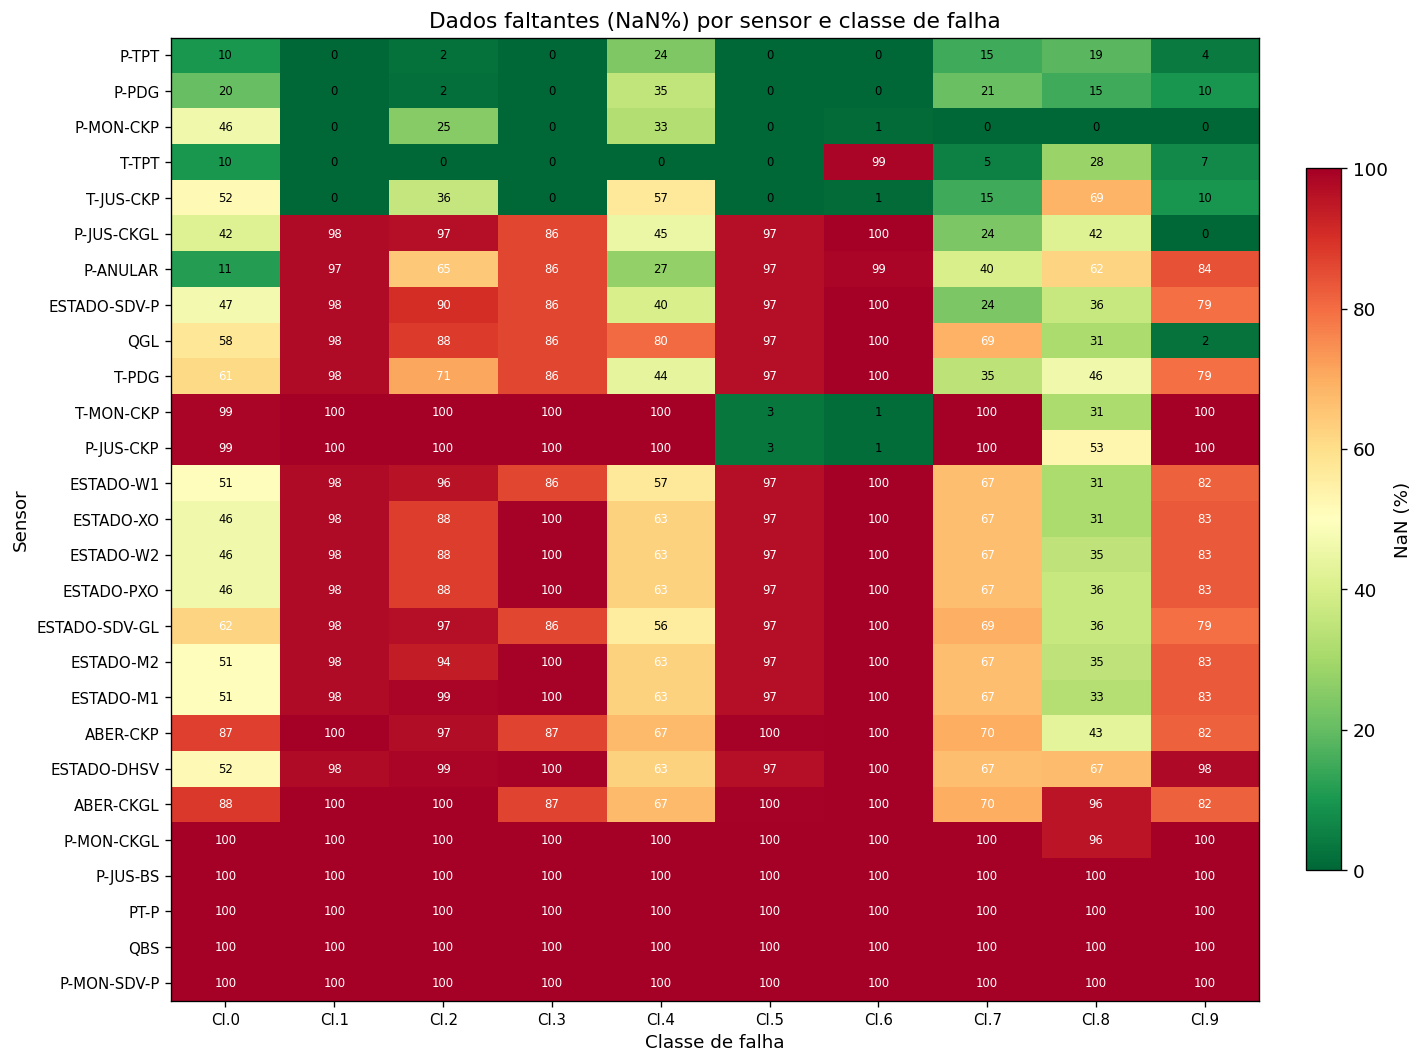

In [9]:
import numpy as np
from pathlib import Path

LATEX_FIGS = Path('../docs/latex/unbtex-example/figuras')

pivot = df_nan.pivot(index='sensor', columns='fault_class', values='nan_pct')
pivot.columns = [f"Cl.{c}" for c in pivot.columns]
sensor_order = pivot.mean(axis=1).sort_values().index
pivot = pivot.loc[sensor_order]

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='NaN (%)', fraction=0.03, pad=0.04)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Classe de falha')
ax.set_ylabel('Sensor')
ax.set_title('Dados faltantes (NaN%) por sensor e classe de falha')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if val > 60 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('../results/figures/eda/nan_sensores_dataset_completo.png', dpi=150, bbox_inches='tight')
plt.savefig(LATEX_FIGS / 'nan_sensores_dataset_completo.png', dpi=150, bbox_inches='tight')
plt.show()

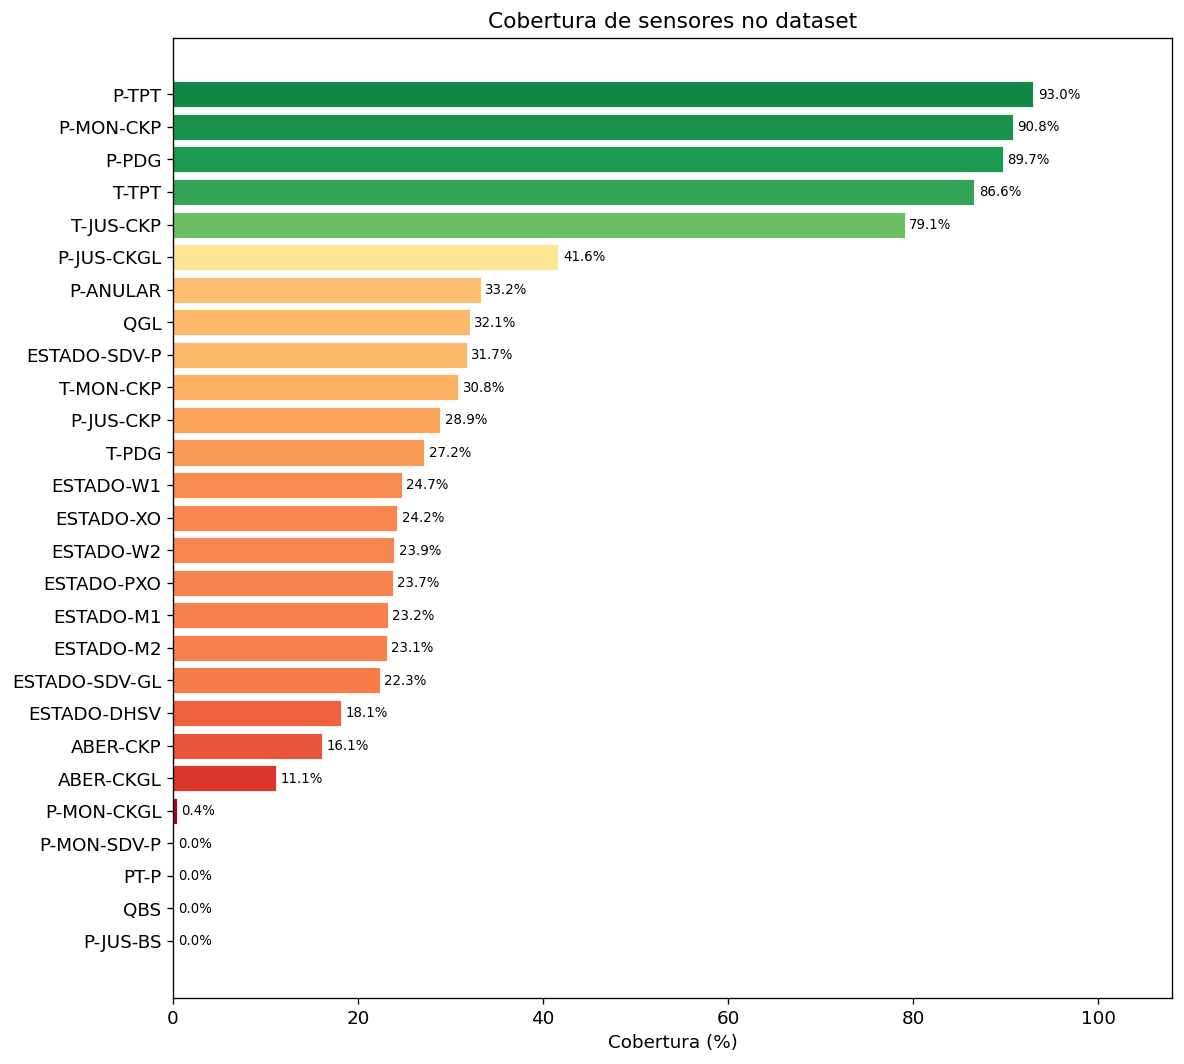

In [5]:
from pathlib import Path
import matplotlib.cm as cm

LATEX_FIGS = Path('../docs/latex/unbtex-example/figuras')

# Cobertura global: amostras válidas / total de amostras, sem separação por classe
total_rows = df_dur['duration'].sum()
n_rows_by_class = df_dur.groupby('fault_class')['duration'].sum()
pivot_cov = df_nan.pivot(index='sensor', columns='fault_class', values='nan_pct')
nan_global = pivot_cov.mul(n_rows_by_class).sum(axis=1).div(total_rows)
coverage = (100 - nan_global).sort_values(ascending=True)

norm = plt.Normalize(0, 100)
colors = [cm.RdYlGn(norm(v)) for v in coverage]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(coverage.index, coverage.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Cobertura (%)')
ax.set_title('Cobertura de sensores no dataset')
ax.set_xlim(0, 108)

for bar, val in zip(bars, coverage.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/eda/ranking_cobertura_sensores.png', dpi=150, bbox_inches='tight')
plt.savefig(LATEX_FIGS / 'ranking_cobertura_sensores.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Duração das instâncias por classe

O janelamento deslizante (Etapa 3) gera janelas de **300 s** com passo de **150 s**. Uma instância com duração $d$ segundos produz aproximadamente $\lfloor(d - 300) / 150\rfloor + 1$ janelas de treino — instâncias com menos de 300 s não geram nenhuma janela.

O boxplot usa **escala logarítmica** no eixo y para acomodar a variação extrema entre instâncias curtas (minutos) e longas (vários dias). A linha vermelha tracejada indica o limite mínimo de 300 s.

A tabela de resumo mostra `N`, `Min`, `Mediana`, `Média`, `Max` e **Janelas/inst** (estimativa baseada na mediana) — útil para prever quantas amostras de treino cada classe vai contribuir.

In [ ]:
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

LATEX_FIGS = Path('../docs/latex/unbtex-example/figuras')

classes_sorted = sorted(FAULT_CLASSES.keys())

summary = (
    df_dur.groupby(['fault_class', 'fault_label'])['duration']
    .agg(N='count', Min='min', Mediana=lambda x: int(x.median()), Media=lambda x: int(x.mean()), Max='max')
    .reset_index()
)
summary['Janelas/inst'] = ((summary['Mediana'] - 300) // 150 + 1).clip(lower=0)
print("Duração por classe (segundos):\n")
print(summary.rename(columns={'fault_label': 'Classe'}).to_string(index=False))

data_by_class = [df_dur[df_dur['fault_class'] == c]['duration'].values for c in classes_sorted]
xlabels = [f"Classe {c}" for c in classes_sorted]

fig, ax = plt.subplots(figsize=(14, 7))
bp = ax.boxplot(
    data_by_class,
    tick_labels=xlabels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.25, color='#555'),
    widths=0.55,
)
for patch in bp['boxes']:
    patch.set_facecolor('#4292c6')
    patch.set_alpha(0.72)

tick_vals = [3600, 10800, 43200, 86400, 259200, 604800]
tick_lbls = ['1 h', '3 h', '12 h', '1 dia', '3 dias', '7 dias']
ax.set_yscale('log')
ax.set_ylim(bottom=3600)
ax.set_yticks(tick_vals)
ax.set_yticklabels(tick_lbls, fontsize=9)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_ylabel('Duração (escala logarítmica)')
ax.set_title('Duração das instâncias por classe de falha')
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.4, which='major')

plt.tight_layout()
plt.savefig('../results/figures/eda/duracao_instancias_por_classe.png', dpi=150, bbox_inches='tight')
plt.savefig(LATEX_FIGS / 'duracao_instancias_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Conclusões da EDA

### Desbalanceamento de classes
O dataset é severamente desbalanceado: classe 0 (Normal) tem 594 instâncias, enquanto DHSV (classe 2) tem apenas 38. A razão máxima chega a ~16:1 em número de instâncias. Em janelas, o desequilíbrio é ainda maior porque instâncias normais tendem a ser mais longas. Solução: `class_weight='balanced'` em todos os modelos e `F1-macro` como métrica principal.

### Sensores problemáticos
Com base no heatmap de NaN (seção 1.5):
- `T-PDG` e `P-PDG`: ausentes em alta proporção — sensor de fundo frequentemente desligado
- `P-JUS-CKGL` e `QGL`: NaN elevado em poços sem gás lift ativo
- Os 8 sensores selecionados para a modelagem são os de maior cobertura consistente

### Padrões visuais por classe
Com base nas séries temporais (seção 1.3):
- **Hidratos (8, 9):** queda progressiva de pressão na árvore de natal molhada (`P-TPT`)
- **Golfadas (3) e Instabilidade (4):** oscilações periódicas em `P-TPT` e `T-TPT`
- **DHSV (2):** colapso abrupto de pressão seguido de recuperação parcial
- **PCK Restrição (6) e Incrustação (7):** queda lenta e gradual de `P-TPT`

### Duração e janelas disponíveis
Com base no boxplot de duração (seção 1.6), todas as classes têm instâncias longas o suficiente para gerar janelas de treino (mínimo de 300 s). Porém, a **variação de duração entre classes é extrema** — um fator determinante no número de janelas disponíveis para o treino:

- **Classes longas** (Normal, Incrustação no PCK, Instabilidade de Fluxo): medianas na ordem de horas a dias, gerando centenas ou milhares de janelas por instância
- **Classes curtas** (DHSV, Golfadas, Hidratos): medianas na ordem de minutos a poucas horas, gerando dezenas de janelas por instância

Essa diferença amplifica o desbalanceamento já observado no número de instâncias: classes raras são também as mais curtas, contribuindo desproporcionalmente pouco para o conjunto de treino.

### Próximos passos
- **Etapa 2:** limpeza (forward-fill ≤ 60 s, z-score por instância, descarte de instâncias com > 50% NaN em P-TPT)
- **Etapa 3:** janelamento deslizante 300 s / 150 s → 88 features estatísticas por janela
- **Etapa 4:** treinamento dos modelos com GroupKFold por `instance_id`
- **Etapa 5:** avaliação dos modelos com f1-score macro
- **Etapa 6:** análise de interpretabilidade dos modelos com SHAP